# 29 — `hexbin`

`Map.hexbin` lays a **fixed hexagonal lattice** over the points and colours each cell by a reduction of the
points inside it. Hexagons have no preferred direction and all share an edge with their six neighbours, so
clusters read as blobs rather than as the blocky artefacts a square grid produces.

Where `quadtree` adapts its cells to the data, `hexbin` keeps every cell the same size — which makes cells
directly comparable and the map easy to read as a density surface.

API: [`Map.hexbin`](../../reference/static_map.md).

**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")


## The data

The 34 Rhine gauges again, so the three aggregation methods can be compared directly.

In [2]:
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
print(f"{len(gauges)} gauges, EPSG:{gauges.crs.to_epsg()}")
gauges["datum(m)"].describe()[["min", "mean", "max"]]

34 gauges, EPSG:3035


C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


min       0.000000
mean     64.602647
max     252.360000
Name: datum(m), dtype: float64

## Quickstart — counting points per cell

Called with no `column`, `hexbin` colours each cell by **how many points fall in it**. That is the pure density
reading.

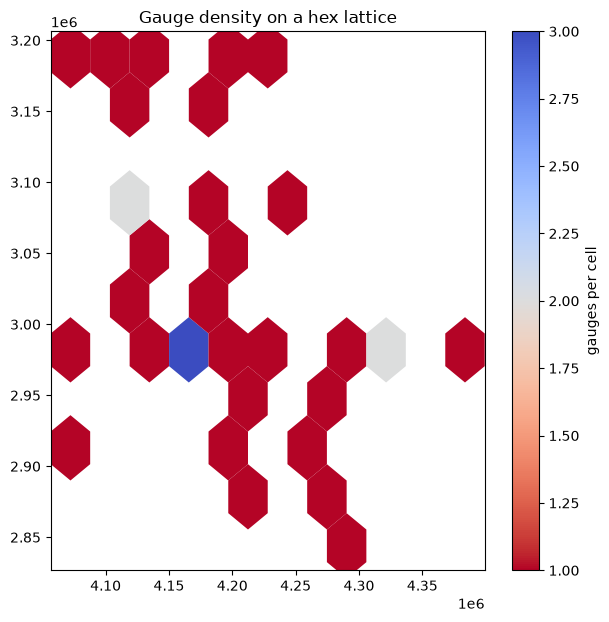

In [3]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.hexbin(gauges, gridsize=10)
m.colorbar(label="gauges per cell")
m.set_title("Gauge density on a hex lattice")
m.fig;

Most cells hold one gauge; the bright cells on the middle Rhine hold several. With only 34 points this is a
sparse map — `hexbin` earns its keep on thousands of points, where a scatter plot would be a solid blob.

## Reducing a value instead of counting

Pass a column and `hexbin` colours each cell by a **reduction over that column** rather than by a count.

| argument | meaning | typical value |
|---|---|---|
| `column` | attribute to reduce | `None` (count) or a numeric column |
| `reduce` | how to combine the values in a cell | `"mean"` (default), `"max"`, `"sum"`, or a callable |
| `gridsize` | cells across the x range — the lattice resolution | `50` (default); smaller = coarser |
| `min_count` | hide cells with fewer than this many points | `None` |

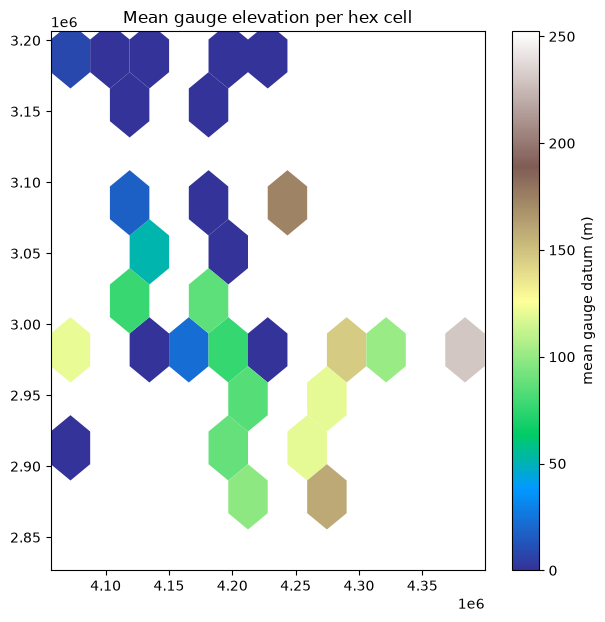

In [4]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.hexbin(gauges, "datum(m)", reduce="mean", gridsize=10, cmap="terrain")
m.colorbar(label="mean gauge datum (m)")
m.set_title("Mean gauge elevation per hex cell")
m.fig;

Now the colour is elevation, not density — the same north-west-low / south-east-high gradient the Voronoi map
showed, but on comparable equal-area cells.

## `gridsize` — the resolution dial

`gridsize` counts cells across the horizontal extent. Too coarse and real structure is averaged away; too fine
and most cells hold a single point, so the map degenerates back into a scatter.

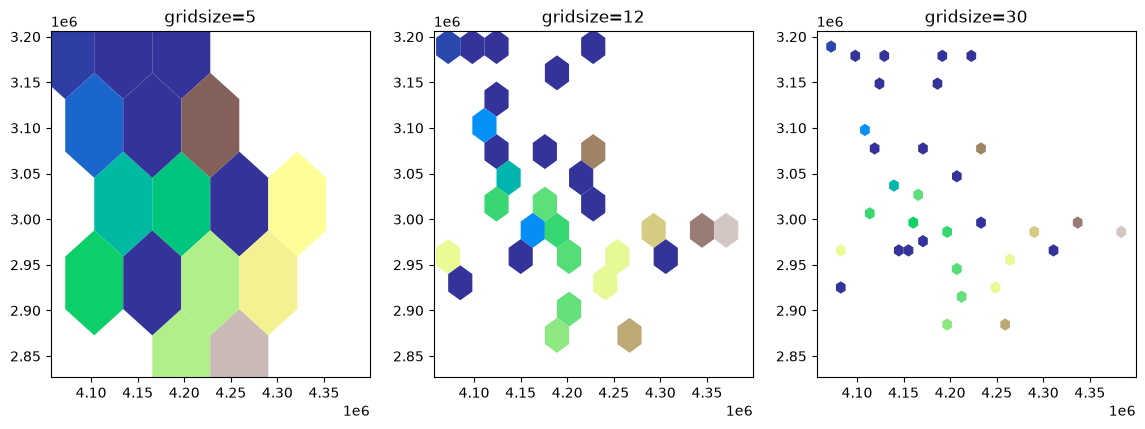

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, gridsize in zip(axes, (5, 12, 30)):
    panel = Map(ax=ax, crs=gauges.crs.to_epsg())
    panel.hexbin(gauges, "datum(m)", gridsize=gridsize, cmap="terrain")
    ax.set_title(f"gridsize={gridsize}")
fig;

Left to right: one smooth gradient, a readable compromise, and a near-scatter. With 34 points `gridsize≈10`
is about the limit; a dataset of 10 000 points would take 50 or more.

## Suppressing thin cells with `min_count`

A cell holding one point reports that point's value with no averaging, which can make outliers look like
regional signal. `min_count` drops those cells entirely.

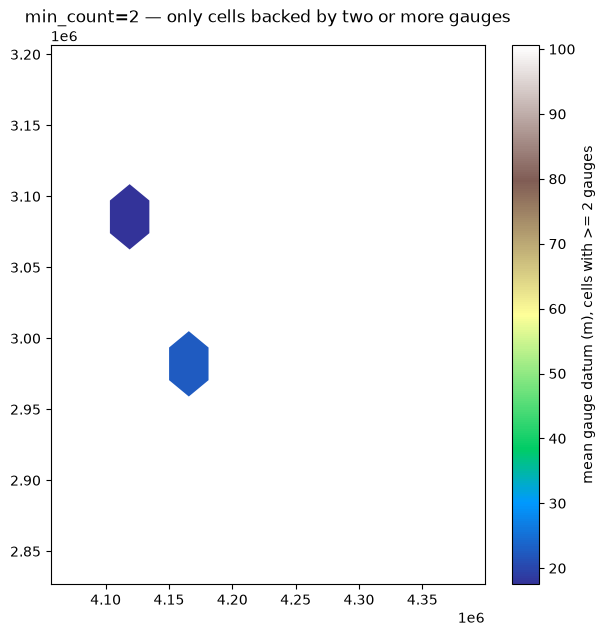

In [6]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.hexbin(gauges, "datum(m)", gridsize=10, min_count=2, cmap="terrain")
m.colorbar(label="mean gauge datum (m), cells with >= 2 gauges")
m.set_title("min_count=2 — only cells backed by two or more gauges")
m.fig;

What remains is the part of the map the data actually supports: the gauge-dense Rhine corridor. Everything
dropped was a single-gauge cell. This is the honest version of the same figure.

## Takeaway

- No `column` → **counts** (density). With a `column` → a **reduction** of that column per cell.
- `gridsize` sets resolution; match it to how many points you have.
- `min_count` removes cells too thin to mean anything — prefer it to letting single points colour a region.
- Equal-sized hexagons make cells comparable, unlike an adaptive `quadtree`.

Next: [`30_kde`](30_kde.ipynb) replaces discrete bins with a continuous density surface.